In [288]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [289]:
def f(x):
    return 3*x**2 - 4*x+5

In [290]:
f(3.0)

20.0

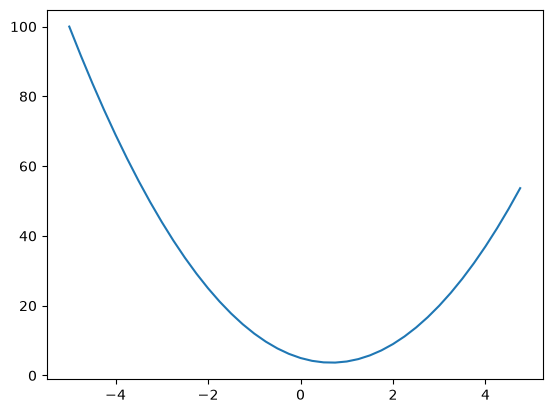

In [291]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [292]:
h = 0.00000000001
x = 2/3
(f(x+h) -f(x))/h

0.0

In [293]:
a=2
b=-3
c=10
d=a*b+c
print(d)

4


In [294]:
h=.0001
a=2
b=-3
c=10

d1=a*b+c
b+=h
d2=a*b+c

print ('d1',d1)
print ('d2',d2)
print ('slope', (d2-d1)/h)

d1 4
d2 4.0002
slope 2.0000000000042206


In [295]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def backward(): 
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = backward
        return out
    def __radd__(self, other):   # other + self
        return self + other
    
    def __rmul__(self, other):
        return self * other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
    
        def _backward(): 
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data / other.data, (self, other), '/')
        def _backward():
            self.grad += (1/other.data) * out.grad
            other.grad += (-self.data/(other.data**2)) * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [296]:
a=Value(2.0)
b=Value(4.0)
a/b

Value(data=0.5)

In [297]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


In [298]:
# Inputs
x1 = Value (2.0, label='x1')
x2 = Value (0.0, label='x2')
# Weights
w1 = Value (-3.0, label='w1')
w2 = Value (1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'
o.backward()

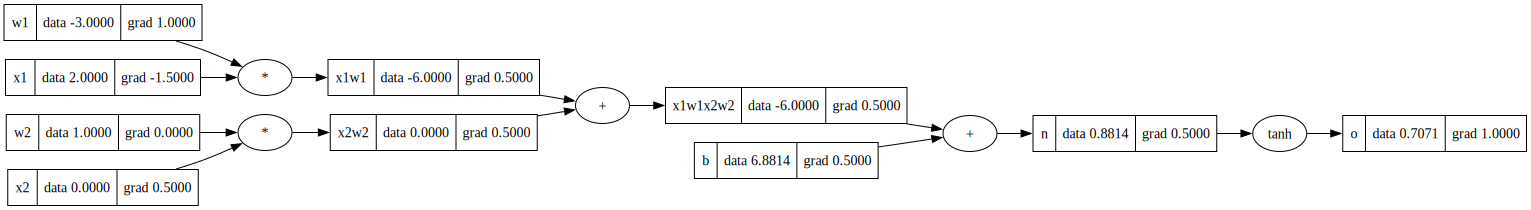

In [299]:
draw_dot(o)

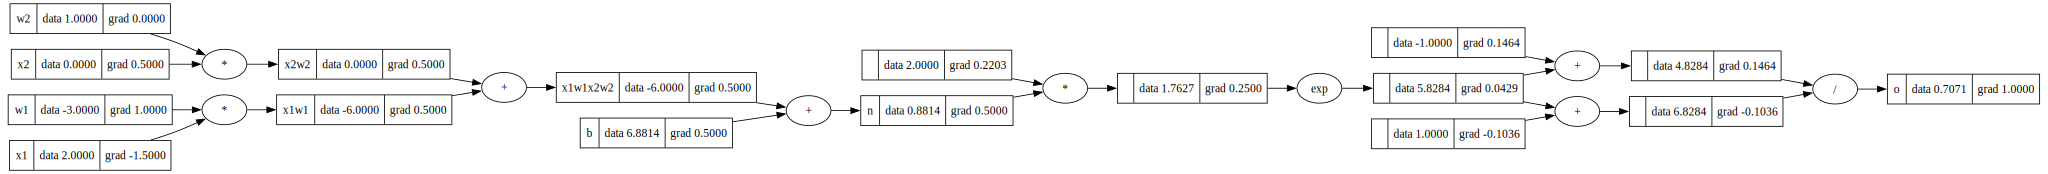

In [300]:
# Inputs
x1 = Value (2.0, label='x1')
x2 = Value (0.0, label='x2')
# Weights
w1 = Value (-3.0, label='w1')
w2 = Value (1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2+b; n.label='n'

e = (2*n).exp()
o=(e-1)/(e+1)

o.label='o'
o.backward()
draw_dot(o)

In [301]:
import torch


In [302]:
x1 = torch.tensor(2.0, requires_grad=True)          ; x1.requieres_grad=True
x2 = torch.tensor(0.0, requires_grad=True)          ; x2.requieres_grad=True
w1 = torch.tensor(-3.0, requires_grad=True)         ; w1.requieres_grad=True
w2 = torch.tensor(1.0, requires_grad=True)          ; w2.requieres_grad=True
b = torch.tensor([6.8813735870195432]).double()     ; b.requieres_grad=True
n = x1*w1+x2*w2+b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x1.grad', x1.grad.item())
print('x2.grad', x2.grad.item())
print('w1.grad', w1.grad.item())
print('w2.grad', w2.grad.item())


0.7071066904050358
-----
x1.grad -1.5000003576278687
x2.grad 0.5000001192092896
w1.grad 1.000000238418579
w2.grad 0.0


In [303]:
torch.tensor([2.0]).double().dtype

torch.float64

In [304]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(np.random.randn()) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [305]:
x=[2.0, 3.0, -1.0]
n=MLP(3, [4, 4, 1])
n(x)

Value(data=-0.7194830475805781)

In [306]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [307]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=14.262661306207088)

In [308]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # zero grad  ← esto es lo que falta
    for p in n.parameters():
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 14.262661306207088
1 7.470986611306218
2 7.244966341902785
3 6.79635037788841
4 5.766309691065808
5 3.5964112587240002
6 2.4589667709492056
7 1.805295518656732
8 1.24398871839159
9 0.8237768382055353
10 0.5447289608651498
11 0.3895410330186918
12 0.3016787056836317
13 0.24360415374126893
14 0.2025649422314467
15 0.17234781065855131
16 0.1493396861205001
17 0.13133075303458297
18 0.1169082574998789
19 0.10513370467091188


In [309]:
ypred

[Value(data=0.8610535887856579),
 Value(data=-0.848750339255107),
 Value(data=-0.8276343212102352),
 Value(data=0.817678272327555)]